In [59]:
# Set CUDA device before importing torch to avoid device conflicts
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from tqdm.auto import tqdm

import models

In [60]:
%config InlineBacke.nd.figure_format = 'retina'
DATA_DIRECTORY = Path("/gpfs/users/leliorzou/earth_data_science/2-volcano-seismology/NVCHVC")
FILES = list(DATA_DIRECTORY.glob("**/*.npy"))
LABELS = {1: "VT", 2: "LP", 3: "TR", 4: "AV", 5: "IC"}

Data shape: 14 channels x 8192 samples


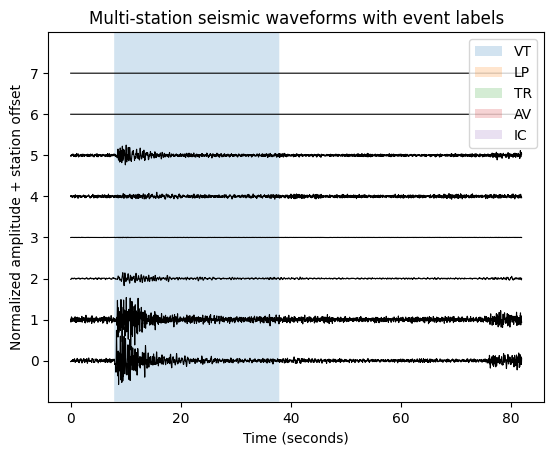

In [61]:
# Randomly select a file
filepath = np.random.choice(FILES)

# Load and inspect the data
sampling_rate = 100
n_stations = 8
data = np.load(filepath)
waveforms = data[:n_stations]
labels = data[n_stations + 1 :]
print(f"Data shape: {data.shape[0]} channels x {data.shape[1]} samples")

# Plot waveforms
fig, ax = plt.subplots(sharex=True)
time = np.arange(data.shape[1]) / sampling_rate
ax.plot(time, waveforms.T + np.arange(8)[None, :], c="k", lw=0.8)

# Label regions
for c, label in enumerate(LABELS.values()):
    ax.fill_between(time, -1, n_stations, labels[c], alpha=0.2, label=label)

# Axes cosmetics
ax.legend()
ax.set(
    xlabel="Time (seconds)",
    ylabel="Normalized amplitude + station offset",
    title="Multi-station seismic waveforms with event labels",
    ylim=(-1, 8),
    yticks=np.arange(8),
)
plt.show()

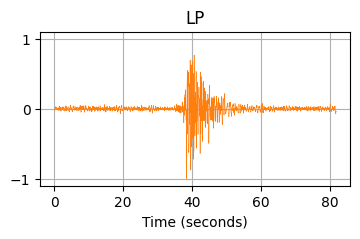

In [62]:
def load_event(filepath, n_stations=8) -> dict:
    """Load a seismic event file and extract the best waveform.

    Parameters
    ----------
    filepath : str or Path
        Path to the .npy file containing seismic event data.
    n_stations : int
        Number of seismic stations (default is 8).

    Returns
    -------
    dict
        A dictionary with keys 'waveform' and 'label'.
    """
    data = np.load(filepath)
    waveforms = data[:n_stations]
    labels = data[n_stations + 1 :]
    amplitudes = np.max(np.abs(waveforms), axis=1)
    best_station = np.argmax(amplitudes)
    waveform = waveforms[best_station] / np.max(
        np.abs(waveforms[best_station])
    )
    label = LABELS[np.argmax(np.sum(labels, axis=1)) + 1]
    return {"waveform": waveform, "label": label}


def get_color(label):
    """Get a color for a given label."""
    return f"C{list(LABELS.values()).index(label)}"


def plot_event(event, ax=None, show=True, **kwargs):
    """Plot the waveform from the event dictionary."""
    kwargs.setdefault("color", get_color(event["label"]))
    kwargs.setdefault("lw", 0.4)
    waveform = event["waveform"]
    label = event["label"]
    time = np.arange(len(waveform)) / sampling_rate
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 2))
    ax.plot(time, waveform, **kwargs)
    ax.set(
        title=label,
        xlabel="Time (seconds)",
        ylim=[-1.1, 1.1],
        yticks=[-1, 0, 1],
    )
    ax.grid()
    if show:
        plt.show()


# Test the function
event = load_event(np.random.choice(FILES))
plot_event(event)

In [63]:
def collect_balanced_data(dirpath, n_per_class=20):
    """Collect balanced samples from each event type."""
    np.random.seed(42)
    events = []
    for event_dir in dirpath.iterdir():
        if event_dir.is_dir():
            files = list(event_dir.glob("*.npy"))
            n_sample = min(n_per_class, len(files))
            if n_sample > 0:
                files = np.random.choice(files, n_sample, replace=False)
                for filepath in files:
                    try:
                        events.append({**load_event(filepath)})
                    except:
                        pass
    return pd.DataFrame(events)


# Display size of the different classes in the form of a bar plot
# Your amazing code goes here
n_class = 100
data = collect_balanced_data(DATA_DIRECTORY, n_per_class=n_class)
data

,waveform,label
0,"[0.006021303077875924, 0.004728733714470733, 0...",IC
1,"[-0.001053963206642871, 0.0034125833990280405,...",IC
2,"[0.048175641485909304, 0.04578475091232541, 0....",IC
3,"[-0.002923961380446697, -0.0027577624653420244...",IC
4,"[-0.01338009275609292, -0.018562795982407634, ...",IC
...,...,...
495,"[0.03733417917084074, 0.03785605827322929, 0.0...",AV
496,"[0.05701920459921066, 0.05330829584064582, 0.0...",AV
497,"[-0.006765738419985554, -0.053379449797533125,...",AV
498,"[-0.016437262750796967, -0.009835669030807574,...",AV


In [64]:
x = np.vstack(data["waveform"].to_numpy())
y_str = data["label"]
y = np.zeros_like(y_str, dtype=int)
y_uniques = np.unique(y_str)
for i, y_unique in enumerate(y_uniques):
    y[y_str == y_unique] = i

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)
print(np.shape(X_train), np.shape(X_test))

(350, 8192) (150, 8192)


In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {str(device).upper()} device.")

Running on CUDA device.


In [67]:
INPUT_SIZE = 8192
N_CLASSES = len(np.unique(y))
HIDDEN_SIZE = 1000
EPOCHS = 50
LEARNING_RATE = 0.1
BATCH_SIZE = 100

model = models.MultiLayerPerceptron(INPUT_SIZE, HIDDEN_SIZE, N_CLASSES)
model = model.to(device)

# Meta information
trainable_parameters = sum([p.numel() for p in model.parameters()])
print(model)
print(f"Number of trainable parameters: {trainable_parameters}")

MultiLayerPerceptron(
  (linear_1): Linear(in_features=8192, out_features=1000, bias=True)
  (activation_1): ReLU()
  (linear_2): Linear(in_features=1000, out_features=5, bias=True)
  (activation_2): Softmax(dim=1)
)
Number of trainable parameters: 8198005


In [68]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

In [69]:
print(type(X_train))

<class 'numpy.ndarray'>


In [70]:
# print(type((X_train.to_numpy())))
# toto = X_train.to_numpy()
# print(np.shape(toto))

In [71]:
test = torch.utils.data.TensorDataset(
    torch.tensor(X_test.astype(np.float32)), torch.tensor(y_test)
)
train = torch.utils.data.TensorDataset(
    torch.tensor(X_train.astype(np.float32)), torch.tensor(y_train)
)

train_loader = torch.utils.data.DataLoader(
    dataset=train, batch_size=BATCH_SIZE, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test, batch_size=BATCH_SIZE, shuffle=False
)

  0%|          | 0/50 [00:00<?, ?it/s]

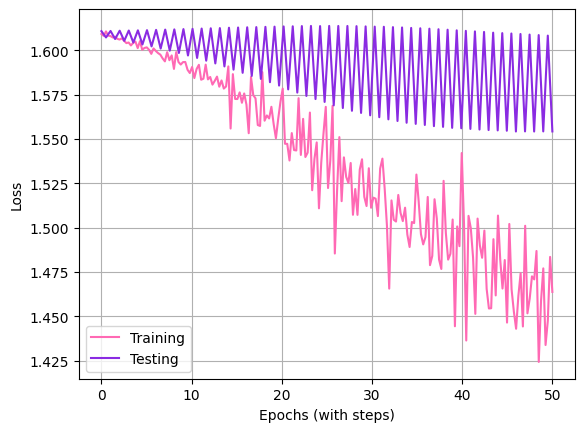

In [72]:
# Initialization
steps = len(train_loader)
loss_train, loss_test = [], []
fig = plt.figure()
ax = plt.axes()

for epoch in tqdm(range(EPOCHS)):

    description = f"Epoch {epoch + 1}/{EPOCHS}"

    for waveform, labels in train_loader:

        # Move tensors to the configured device and reshape
        waveform = waveform.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(waveform)
        loss = criterion(outputs, labels)
        loss_train.append(loss.item())

        # Set the gradients to zero before starting to do backpropragation
        # because PyTorch accumulates the gradients on subsequent backward passes
        optimizer.zero_grad()

        # Calculate the gradients by performing a backward pass and update
        loss.backward()
        optimizer.step()

    # Test the model (don't need to compute gradients)
    with torch.no_grad():

        for waveform, labels in test_loader:

            # Move tensors to the configured device
            waveform = waveform.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(waveform)
            loss = criterion(outputs, labels)
            loss_test.append(loss.item())

    # Plot loss
    ax.cla()
    epochs_train = np.linspace(0, epoch + 1, len(loss_train))
    epochs_test = np.linspace(0, epoch + 1, len(loss_test))
    ax.plot(epochs_train, loss_train, label="Training", color="hotpink")
    ax.plot(epochs_test, loss_test, label="Testing", color="blueviolet")
    ax.legend()
    ax.grid()
    ax.set_xlabel("Epochs (with steps)")
    ax.set_ylabel("Loss")
    fig.savefig("loss_fcnn.png", bbox_inches="tight")